# SinBERT-large Baseline — 5-Fold Stratified CV


### Configuration

In [1]:
#Installing dependancies
!pip install transformers sentencepiece -q


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#Paths
BASE_PATH = "/content/drive/MyDrive/Newslens.lk/phase_2"
RESULTS_DIR = f"{BASE_PATH}/results/sinbert"

# Config
MODEL_NAME = "NLPC-UOM/SinBERT-large"
MAX_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 4
LR = 2e-5
PATIENCE = 2
N_FOLDS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cuda


### Data loading

In [4]:
df = pd.read_csv(f"{BASE_PATH}/phase2_cleaned.csv")

with open(f"{BASE_PATH}/label_mapping.json", "r") as f:
    label_map = json.load(f)

id_to_label = {v: k for k, v in label_map.items()}
df["label_id"] = df["bias_label"].map(label_map)

print(f"Samples: {len(df)}")
print(f"\nLabel mapping: {label_map}")
print(f"\nClass distribution:")
print(df["bias_label"].value_counts())
print(f"\nNull check: {df[['text', 'label_id']].isnull().sum().to_dict()}")


Samples: 1655

Label mapping: {'Far Left': 0, 'Left': 1, 'Center': 2, 'Right': 3, 'Far Right': 4}

Class distribution:
bias_label
Center       740
Left         370
Right        339
Far Left     123
Far Right     83
Name: count, dtype: int64

Null check: {'text': 0, 'label_id': 0}


### Tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Quick tokenization check
sample = tokenizer(df["text"].iloc[0], max_length=MAX_LENGTH, truncation=True)
print(f"Sample token count: {len(sample['input_ids'])}")
print(f"Vocab size: {tokenizer.vocab_size}")



config.json:   0%|          | 0.00/722 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.15M [00:00<?, ?B/s]

Sample token count: 512
Vocab size: 52000


### Training and Evaluation

In [6]:
def train_one_epoch(model, dataloader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, macro_f1, all_preds, all_labels


### 5 fold cross validation

In [7]:
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

texts = df["text"].values
labels = df["label_id"].values

fold_f1_results = []
fold_acc_results = []
all_fold_preds = []
all_fold_labels = []
best_global_f1 = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold + 1}/{N_FOLDS}")
    print(f"{'='*50}")

    train_dataset = NewsDataset(texts[train_idx].tolist(), labels[train_idx].tolist())
    val_dataset = NewsDataset(texts[val_idx].tolist(), labels[val_idx].tolist())

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_loss, val_f1, _, _ = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{EPOCHS} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Load best model for this fold and evaluate
    model.load_state_dict(best_model_state)
    _, fold_f1, fold_preds, fold_labels = evaluate(model, val_loader)
    fold_acc = accuracy_score(fold_labels, fold_preds)

    fold_f1_results.append(fold_f1)
    fold_acc_results.append(fold_acc)
    all_fold_preds.extend(fold_preds)
    all_fold_labels.extend(fold_labels)

    print(f"\nFold {fold+1} — Macro-F1: {fold_f1:.4f} | Accuracy: {fold_acc:.4f}")
    print(classification_report(fold_labels, fold_preds, target_names=list(label_map.keys())))

    # Save best model globally
    if fold_f1 > best_global_f1:
        best_global_f1 = fold_f1
        os.makedirs(f"{RESULTS_DIR}/best_checkpoint", exist_ok=True)
        model.save_pretrained(f"{RESULTS_DIR}/best_checkpoint")
        tokenizer.save_pretrained(f"{RESULTS_DIR}/best_checkpoint")
        print(f"Saved best model (Fold {fold+1})")

print(f"\n{'='*50}")
print(f"RESULTS ACROSS ALL FOLDS")
print(f"{'='*50}")
print(f"Macro-F1:  {np.mean(fold_f1_results):.4f} ± {np.std(fold_f1_results):.4f}")
print(f"Accuracy:  {np.mean(fold_acc_results):.4f} ± {np.std(fold_acc_results):.4f}")
for i in range(len(fold_f1_results)):
    print(f"  Fold {i+1}: F1={fold_f1_results[i]:.4f} | Acc={fold_acc_results[i]:.4f}")



FOLD 1/5


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  504MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 — Train Loss: 1.2961 | Val Loss: 1.1368 | Val Macro-F1: 0.2604
Epoch 2/4 — Train Loss: 1.0857 | Val Loss: 1.0947 | Val Macro-F1: 0.2977
Epoch 3/4 — Train Loss: 0.9741 | Val Loss: 1.0790 | Val Macro-F1: 0.3251
Epoch 4/4 — Train Loss: 0.9035 | Val Loss: 1.0835 | Val Macro-F1: 0.3299

Fold 5 — Macro-F1: 0.3299 | Accuracy: 0.5710
              precision    recall  f1-score   support

    Far Left       0.00      0.00      0.00        25
        Left       0.41      0.50      0.45        74
      Center       0.75      0.82      0.78       148
       Right       0.38      0.45      0.41        67
   Far Right       0.00      0.00      0.00        17

    accuracy                           0.57       331
   macro avg       0.31      0.35      0.33       331
weighted avg       0.50      0.57      0.54       331


RESULTS ACROSS ALL FOLDS
Macro-F1:  0.3396 ± 0.0215
Accuracy:  0.5728 ± 0.0223
  Fold 1: F1=0.3661 | Acc=0.5740
  Fold 2: F1=0.3038 | Acc=0.5347
  Fold 3: F1=0.3543 | Acc=0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion matrix with the results

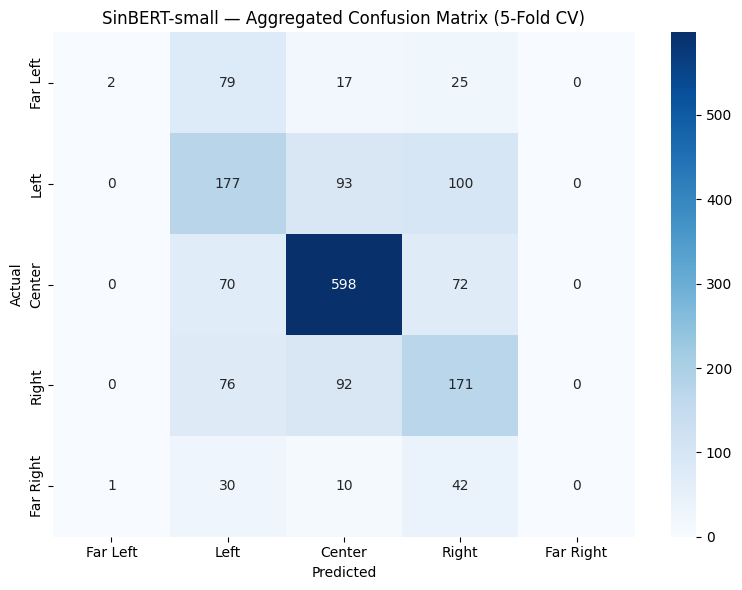


Overall Classification Report (all folds combined):
              precision    recall  f1-score   support

    Far Left       0.67      0.02      0.03       123
        Left       0.41      0.48      0.44       370
      Center       0.74      0.81      0.77       740
       Right       0.42      0.50      0.46       339
   Far Right       0.00      0.00      0.00        83

    accuracy                           0.57      1655
   macro avg       0.45      0.36      0.34      1655
weighted avg       0.56      0.57      0.54      1655



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# Aggregated confusion matrix
os.makedirs("results/sinbert", exist_ok=True)
label_names = list(label_map.keys())

cm = confusion_matrix(all_fold_labels, all_fold_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SinBERT-small — Aggregated Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.savefig("results/sinbert/confusion_matrix.png", dpi=150)
plt.show()

# Overall classification report
print("\nOverall Classification Report (all folds combined):")
report = classification_report(all_fold_labels, all_fold_preds, target_names=label_names)
print(report)


In [9]:
# Save results report
report_dict = classification_report(all_fold_labels, all_fold_preds, target_names=label_names, output_dict=True)

with open("results/sinbert/results_report.md", "w") as f:
    f.write("# SinBERT-small Baseline Results\n\n")
    f.write(f"**Model**: `{MODEL_NAME}`\n\n")
    f.write(f"**Config**: max_length={MAX_LENGTH}, batch_size={BATCH_SIZE}, lr={LR}, epochs={EPOCHS}, patience={PATIENCE}\n\n")
    f.write(f"## Cross-Validation Macro-F1\n\n")
    f.write(f"**Mean: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}**\n\n")
    f.write("| Fold | Macro-F1 |\n|------|----------|\n")
    for i, f1 in enumerate(fold_results):
        f.write(f"| {i+1} | {f1:.4f} |\n")
    f.write(f"\n## Per-Class Results (All Folds Combined)\n\n")
    f.write("| Class | Precision | Recall | F1-Score | Support |\n")
    f.write("|-------|-----------|--------|----------|---------|\n")
    for label in label_names:
        r = report_dict[label]
        f.write(f"| {label} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1-score']:.4f} | {int(r['support'])} |\n")
    f.write(f"\n## Confusion Matrix\n\n![Confusion Matrix](confusion_matrix.png)\n")

print("Results saved to results/sinbert/results_report.md")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NameError: name 'fold_results' is not defined